# 지경학적 분절화는 서비스 교역에서도 일어나는가 — 재현 노트북

`paper.md`의 그림 셋을 다시 그리고, 본문이 인용한 수치를 하나씩 대조한다. 지표와 블록 배정을
계산하는 원 코드는 `research/03-fragmentation-extended/reproduce.ipynb`이며, 이 노트북은 그 산출물인
`out/`의 CSV와 `out/stats.json`을 읽는다. III.5절이 인용하는 표본 포괄률만은 그 산출물에 없으므로
§4에서 서비스 교역 DB를 직접 읽어 따로 구한다. DB가 없으면 그 절만 건너뛰고 나머지는 그대로 돌아간다.

차례: §0 설정 · §1 그림 1 · §2 그림 2 · §3 그림 3 · §4 교역망의 표본 포괄 · §5 본문 수치 검증

## §0. 설정

연구 3의 산출물 폴더를 찾고 그림 표준을 맞춘다. 표준은 연구 3와 같다. 흑백, 300dpi,
Malgun Gothic, 위·오른쪽 축선 제거, 격자 0.87이다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from matplotlib.ticker import MultipleLocator

HERE = Path.cwd()
if not (HERE / "paper.md").exists() and (HERE / "research" / "02-fragmentation").exists():
    HERE = HERE / "research" / "02-fragmentation"
assert (HERE / "paper.md").exists(), f"연구 폴더에서 실행한다 (지금: {HERE})"
SRC = HERE.parent / "03-fragmentation-extended" / "out"
assert SRC.exists(), f"연구 3의 산출물이 없다: {SRC}"
IMG = HERE / "img"
IMG.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "Malgun Gothic", "axes.unicode_minus": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "0.87", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
})


def year_axis(ax, step=2):
    ax.xaxis.set_major_locator(MultipleLocator(step))
    ax.xaxis.set_major_formatter(lambda v, pos: f"{int(v)}")


# 띠는 비교 구간, 점선은 사건의 시작. 두 표기가 각각 한 가지만 맡는다.
SPANS = ((2014.5, 2017.5, "사전"), (2021.5, 2024.5, "사후"))
MARKS = ((2018, "관세"), (2020, "코로나"))


def mark_periods(ax, label=True):
    for lo, hi, _ in SPANS:
        ax.axvspan(lo, hi, color="0.90", lw=0, zorder=0)
    for x, _ in MARKS:
        ax.axvline(x, color="0.55", lw=0.8, ls=":", zorder=0)
    if label:
        tr = ax.get_xaxis_transform()
        for lo, hi, name in SPANS:
            ax.text((lo + hi) / 2, 0.99, name, transform=tr, ha="center", va="top",
                    fontsize=8, fontweight="bold", color="0.35")
        for x, name in MARKS:
            ax.text(x + 0.12, 0.99, name, transform=tr, ha="left", va="top",
                    fontsize=8, fontweight="bold", color="0.35")


S = json.load(open(SRC / "stats.json", encoding="utf-8"))
ann = pd.read_csv(SRC / "annual_D1.csv", index_col=0)
cat = pd.read_csv(SRC / "annual_category_D1.csv", index_col=0)
net = pd.read_csv(SRC / "network_ari.csv", index_col=0)
mc = pd.read_csv(SRC / "main_changes.csv").set_index(["defn", "series"])
print(HERE, "|", SRC)

C:\Work\Projects\Services\research\02-fragmentation | C:\Work\Projects\Services\research\03-fragmentation-extended\out


## §1. 그림 1 — 블록 간 교역 비중의 추이

기준안 블록 구분에서 상품과 서비스의 연도별 블록 간 교역 비중이다. 연구 3의 그림 1이 두 칸에
세 계열을 그린 것과 달리, 이 논문은 한 칸에 두 기준 계열만 그린다.

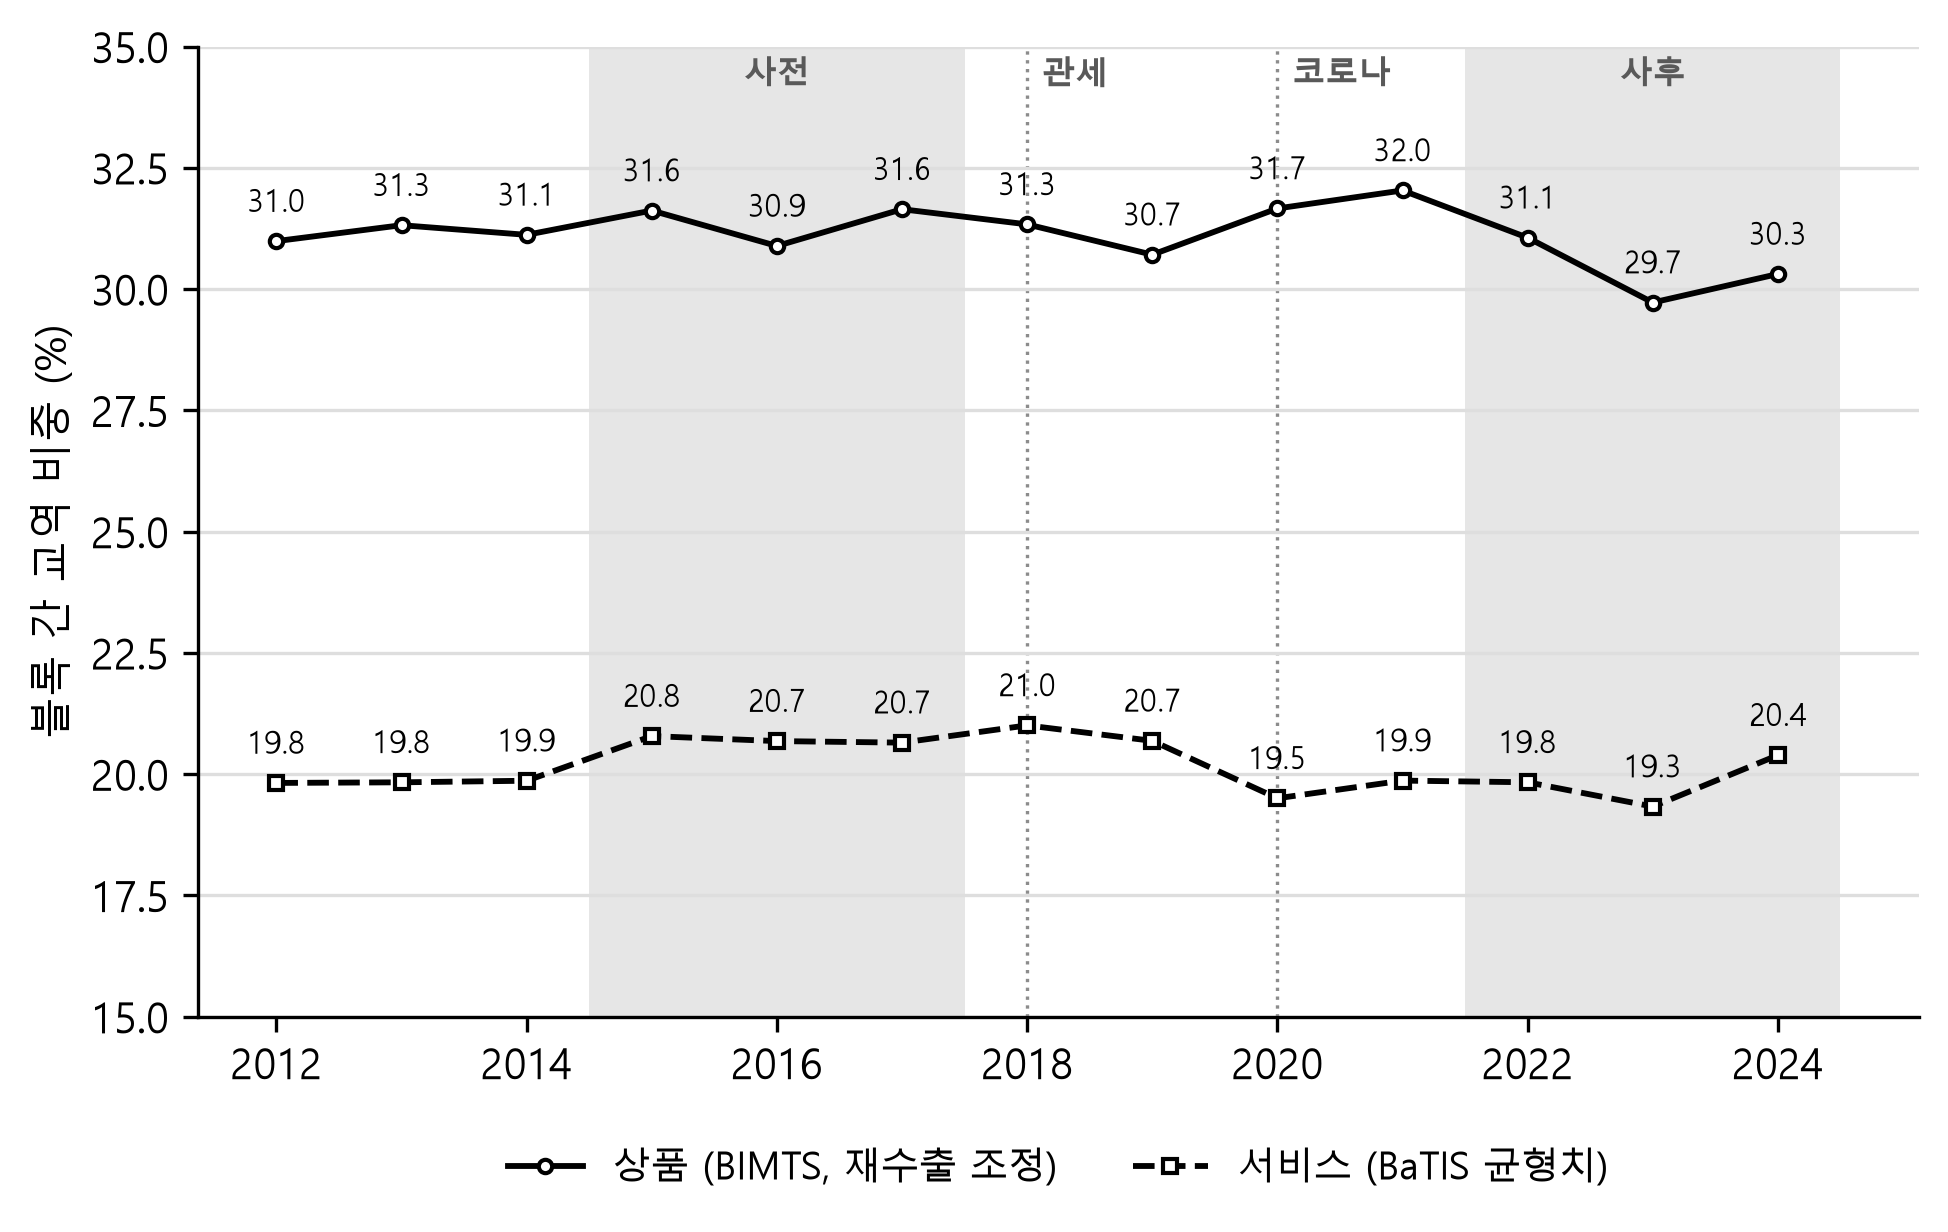

In [2]:
fig, ax = plt.subplots(figsize=(7.4, 4.2))
mark_periods(ax)
series = [(ann.goods_rx, "-", "o", "상품 (BIMTS, 재수출 조정)"),
          (ann.svc_bal, "--", "s", "서비스 (BaTIS 균형치)")]
for y, ls, mk, lab in series:
    ax.plot(ann.index, y, color="black", lw=1.4, ls=ls,
            marker=mk, ms=3.2, mfc="white", mec="black", label=lab)
    for x, v in zip(ann.index, y):
        ax.annotate(f"{v:.1f}", (x, v), textcoords="offset points", xytext=(0, 7),
                    ha="center", fontsize=7.5)
ax.set_ylabel("블록 간 교역 비중 (%)")
ax.set_ylim(15, 35)
ax.legend(ncol=2, loc="upper center", fontsize=9, bbox_to_anchor=(0.5, -0.1))
year_axis(ax)
fig.savefig(IMG / "fig1_cross_share.png")
plt.close(fig)
display(Image(IMG / "fig1_cross_share.png", width=740))


## §2. 그림 2 — 서비스 범주별 블록 간 교역 비중

다섯 범주 가운데 본문이 다루는 넷을 그리고, 비교를 위해 상품의 블록 간 비중을 옅은 점선으로
함께 둔다. 연구 3의 그림 2와 같은 구성이다.

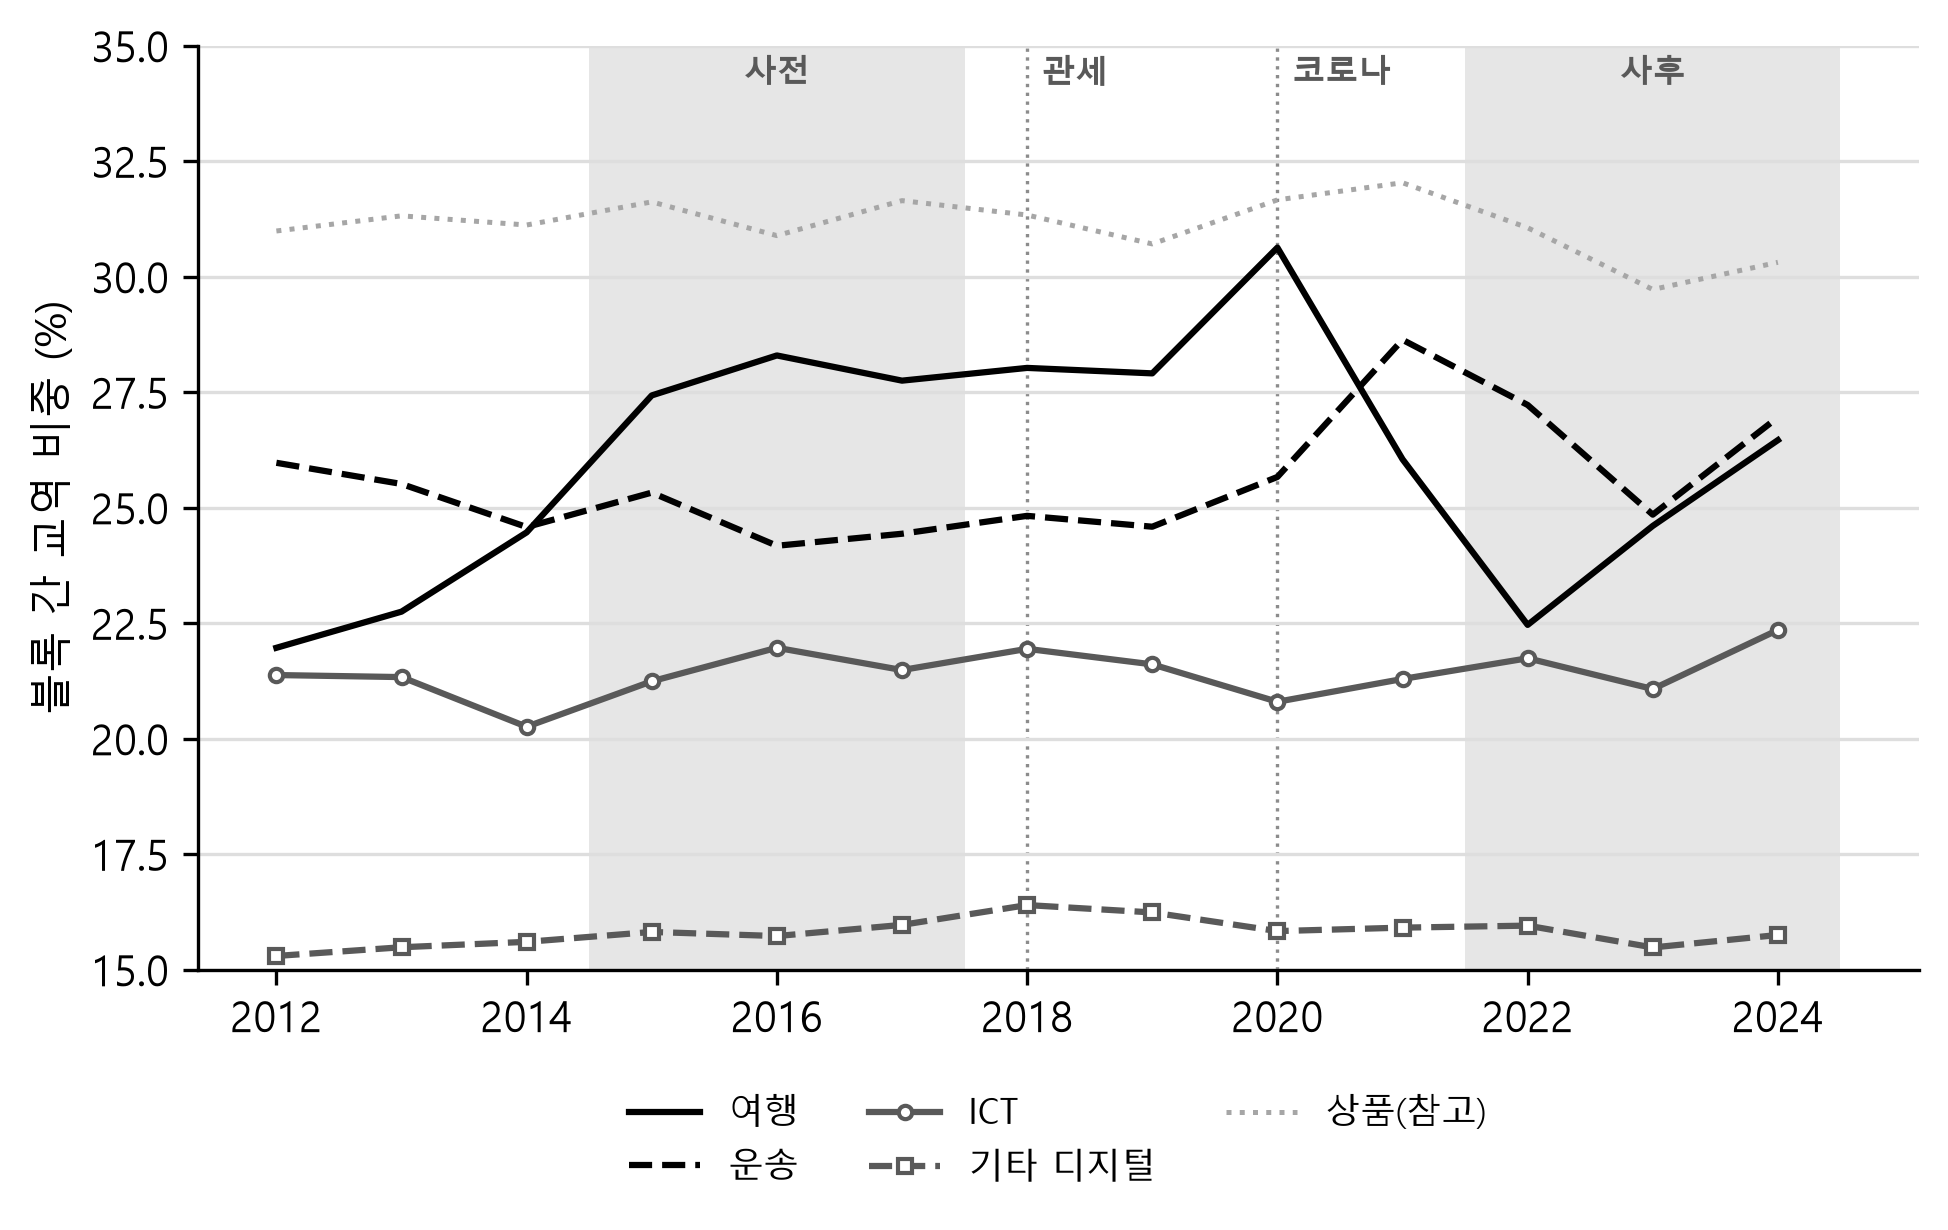

In [3]:
fig, ax = plt.subplots(figsize=(7.4, 4.0))
mark_periods(ax)
style = {"여행": ("black", "-", None), "운송": ("black", "--", None), "ICT": ("0.35", "-", "o"),
         "기타 디지털": ("0.35", "--", "s")}
for g, (c, ls, mk) in style.items():
    ax.plot(cat.index, cat[g], color=c, ls=ls, lw=1.5, marker=mk, ms=3.2, mfc="white", mec=c, label=g)
ax.plot(ann.index, ann.goods_rx, color="0.65", lw=1.2, ls=":", label="상품(참고)")
ax.set_ylabel("블록 간 교역 비중 (%)")
ax.set_ylim(15, 35)
ax.legend(ncol=3, loc="upper center", fontsize=8.5, bbox_to_anchor=(0.5, -0.1))
year_axis(ax)
fig.savefig(IMG / "fig2_categories.png")
plt.close(fig)
display(Image(IMG / "fig2_categories.png", width=740))

## §3. 그림 3 — 교역망의 블록 모듈러리티

블록 구분을 교역망에 그대로 적용했을 때의 가중 모듈러리티다. 연구 3의 그림 3은 조정 랜드 지수를
함께 실었으나, 그 지표는 군집 수에 좌우되어 구조 변화의 증거로 쓰지 않으므로 여기서는 뺐다.

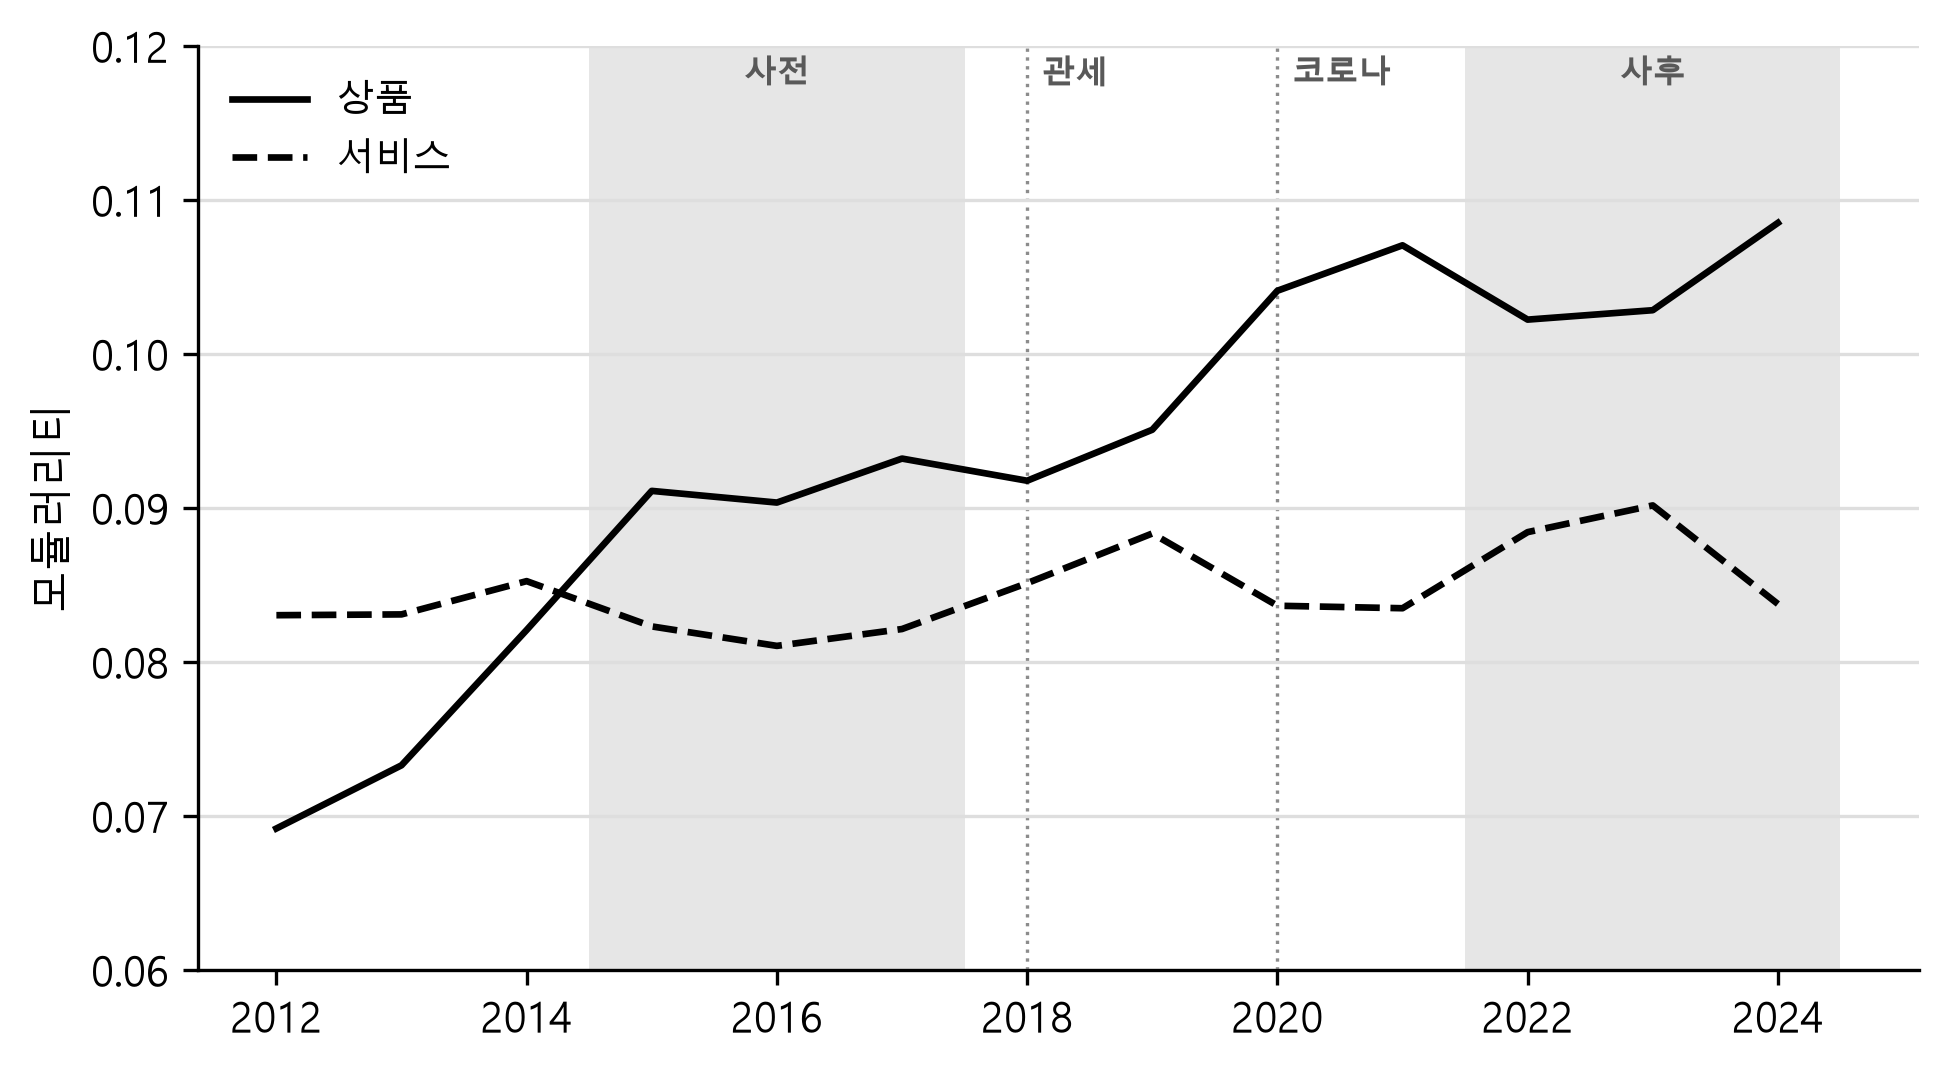

In [4]:
fig, ax = plt.subplots(figsize=(7.4, 4.0))
mark_periods(ax)
ax.plot(net.index, net.goods_q_d1, color="black", lw=1.6, label="상품")
ax.plot(net.index, net.svc_q_d1, color="black", lw=1.6, ls="--", label="서비스")
ax.set_ylabel("모듈러리티")
ax.set_ylim(0.06, 0.12)
ax.yaxis.set_major_locator(MultipleLocator(0.01))
ax.legend(loc="upper left", fontsize=9)
year_axis(ax)
fig.savefig(IMG / "fig3_modularity.png")
plt.close(fig)
display(Image(IMG / "fig3_modularity.png", width=740))

## §4. 교역망의 표본 포괄

III.5절은 교역망만 표본이 아니라 전체 균형치로 만든다고 적고, 표본으로 만들면 상위 80개 경제
사이에서도 쌍의 절반 남짓만 남는다는 것을 근거로 든다. 그 수치는 연구 3의 산출물에 없으므로
여기서 DB를 직접 읽어 구한다. 표본을 다시 만들어 보는 셈이므로, 쌍의 수가 연구 3의 9,196개와
같은지를 먼저 확인한 뒤 센다.

In [5]:
# 이 절만 서비스 교역 DB가 필요하다. 없으면 건너뛴다.
DB = HERE.parents[1] / "data" / "processed" / "svcdb.duckdb"
PANEL_YEARS = (2015, 2016, 2017, 2022, 2023)
# 잔여 코드 WXD(나머지 세계)는 II.1절이 밝힌 대로 표본에서 뺀다.

if not DB.exists():
    net_gap = None
    print(f"DB가 없어 건너뛴다: {DB}")
else:
    import duckdb

    con = duckdb.connect()
    con.execute(f"ATTACH '{DB.as_posix()}' AS s (READ_ONLY)")
    pairs = con.execute(f"""
    WITH e AS (SELECT year, reporter i, partner j, reported_value rx
               FROM s.fact_batis WHERE flow='EXP' AND item_code='S'),
         m AS (SELECT year, partner i, reporter j, reported_value rm
               FROM s.fact_batis WHERE flow='IMP' AND item_code='S'),
         u AS (SELECT e.year, e.i, e.j, e.rx, m.rm FROM e LEFT JOIN m USING (year, i, j)
               JOIN s.dim_area ai ON e.i = ai.code AND NOT ai.is_aggregate
               JOIN s.dim_area aj ON e.j = aj.code AND NOT aj.is_aggregate)
    SELECT i, j FROM u WHERE year IN {PANEL_YEARS} AND i <> 'WXD' AND j <> 'WXD'
    GROUP BY 1, 2
    HAVING sum((rx IS NOT NULL OR rm IS NOT NULL)::INT) = {len(PANEL_YEARS)}
    """).df()
    top = con.execute("""
    WITH t AS (SELECT reporter c, sum(balanced_value) v FROM s.fact_batis
               WHERE item_code = 'S' AND flow IN ('EXP', 'IMP') AND partner = 'W'
                 AND year BETWEEN 2015 AND 2017 GROUP BY 1)
    SELECT c FROM t JOIN s.dim_area a ON t.c = a.code AND NOT a.is_aggregate
    ORDER BY v DESC LIMIT 80
    """).df().c.tolist()
    con.close()

    assert len(pairs) == S["panel"]["n_pairs"],         f"표본을 다시 만든 결과가 산출물과 다르다: {len(pairs)} != {S['panel']['n_pairs']}"
    node = set(top)
    n_in = int((pairs.i.isin(node) & pairs.j.isin(node)).sum())
    n_all = len(top) * (len(top) - 1)
    net_gap = {"n_nodes": len(top), "pairs_all": n_all, "pairs_in": n_in,
               "pct": 100 * n_in / n_all}
    print(f"상위 {len(top)}개 경제의 유향 쌍 {n_all:,}개 가운데 표본에 드는 것 "
          f"{n_in:,}개 ({net_gap['pct']:.1f}%)")


상위 80개 경제의 유향 쌍 6,320개 가운데 표본에 드는 것 3,590개 (56.8%)


## §5. 본문 수치 검증

`paper.md`가 인용한 값을 `out/`의 산출물과 대조한다. 본문을 고치면 이 절도 함께 고친다.
어긋나면 `AssertionError`로 멈춘다.

In [6]:
def chk(name, got, want, tol=0.006):
    ok = got is not None and abs(got - want) <= tol
    print(("OK  " if ok else "FAIL") + f" {name}: 계산 {got} / 본문 {want}")
    assert ok, f"{name}: 계산 {got} != 본문 {want}"


M, P, B = S["main"], S["panel"], S["blocs"]
svc, gds = M["D1|svc_bal"], M["D1|goods_rx"]

# II.1 표본
chk("표본 흐름 수", P["n_pairs"], 9192, 0)
chk("표본 경제 수", P["n_economies"], 200, 0)
chk("서비스 포괄 2019", P["svc_cover_2019"], 82.2, 0.05)
chk("서비스 포괄 2023", P["svc_cover_2023"], 83.8, 0.05)
chk("상품 포괄 2019", P["goods_cover_2019"], 75.8, 0.05)
chk("상품 포괄 2023", P["goods_cover_2023"], 74.1, 0.05)
assert P["usa_chn_in"]
RR = S["report_rate"]
chk("미국 상대별 보고 사전", RR["USA_pre"], 35.5, 0.05)
chk("미국 상대별 보고 사후", RR["USA_post"], 94.0, 0.05)
chk("러시아 상대별 보고 사전", RR["RUS_pre"], 96.5, 0.05)
chk("러시아 상대별 보고 사후", RR["RUS_post"], 0.0, 0.05)
RC = P["rep_complete"]
chk("보고 완결도 2012", RC["2012"], 91.4, 0.05)
chk("보고 완결도 2013", RC["2013"], 95.5, 0.05)
chk("보고 완결도 2024", RC["2024"], 72.9, 0.05)
assert min(RC[str(y)] for y in range(2014, 2024)) >= 99.0

# II.2 블록
# 블록 경제 수는 표본 안에서 센다. 사분위의 경계는 이념점수가 있는 경제 전체에서 구한다.
chk("이념점수가 있는 경제", S["idealpoint"]["n_pre"], 193, 0)
chk("미국 측 블록", B["panel"]["D1"]["US"], 54, 0)
chk("중국 측 블록", B["panel"]["D1"]["CN"], 51, 0)
chk("비동맹", B["panel"]["D1"]["NON"], 93, 0)
chk("미배정", B["panel"]["D1"]["none"], 2, 0)
chk("표본 경제 수(블록표)", B["panel_n"], 200, 0)

# III.1 그림 1 인용. 본문은 소수 한 자리로 적으므로 그림 라벨과 같은 자료에서 같은 값을 본다.
F1 = {("서비스", 2017): 20.7, ("서비스", 2019): 20.7, ("서비스", 2020): 19.5,
      ("서비스", 2023): 19.3, ("서비스", 2024): 20.4,
      ("상품", 2017): 31.6, ("상품", 2019): 30.7, ("상품", 2021): 32.0,
      ("상품", 2023): 29.7, ("상품", 2024): 30.3}
COL = {"서비스": "svc_bal", "상품": "goods_rx"}
for (nm, y), want in F1.items():
    chk(f"{nm} {y}", round(float(ann.loc[y, COL[nm]]), 1), want, 0)
chk("상품 2017→2019 낙폭", round(float(ann.loc[2017, "goods_rx"] - ann.loc[2019, "goods_rx"]), 1), 0.9, 0)
assert ann.loc[2021, "goods_rx"] > ann.loc[2017, "goods_rx"], "2021년 상품이 2017년 수준을 넘는다"

# III.2 표 1
chk("서비스 사전 수준", svc["S_pre"], 20.70); chk("상품 사전 수준", gds["S_pre"], 31.39)
chk("서비스 사전 추세", svc["d_pretrend"], 0.86); chk("상품 사전 추세", gds["d_pretrend"], 0.25)
chk("서비스 무역분쟁", svc["d_war"], 0.14); chk("상품 무역분쟁", gds["d_war"], -0.37)
chk("서비스 사후", svc["d_post"], -0.84); chk("상품 사후", gds["d_post"], -1.02)
chk("서비스 로그 오즈", svc["dlogodds_post"], -0.052, 0.0006)
chk("상품 로그 오즈", gds["dlogodds_post"], -0.048, 0.0006)
gap = round(abs(mc.loc[("D1", "svc_bal"), "dlogodds_post"]
                - mc.loc[("D1", "goods_rx"), "dlogodds_post"]), 3)
assert gap <= 0.005, f"로그 오즈 차이 {gap}을 미미하다고 보기 어렵다"
print(f"OK   로그 오즈 차이: {gap} (본문: 미미하다)")

BT = S["bootstrap_D1"]
chk("부트스트랩 수출국", BT["n_exporters"], 105, 0)
chk("부트스트랩 반복", BT["svc_bal"]["n"], 1000, 0)
chk("서비스 구간 하한", BT["svc_bal"]["lo"], -2.11); chk("서비스 구간 상한", BT["svc_bal"]["hi"], 0.81)
chk("상품 구간 하한", BT["goods_rx"]["lo"], -2.44); chk("상품 구간 상한", BT["goods_rx"]["hi"], 0.47)
chk("차이 구간 하한", BT["diff_bal"]["lo"], -1.09); chk("차이 구간 상한", BT["diff_bal"]["hi"], 1.77)

# III.3 표 2와 범주
D = S["decomp"]["D1"]
T2 = {"여행": (21.73, 16.36, 27.83, 24.79, -3.04, -1.41, -0.58, -1.99),
      "운송": (16.74, 17.24, 24.65, 26.38, 1.73, 0.13, 0.29, 0.42),
      "ICT": (8.86, 11.75, 21.56, 21.74, 0.18, 0.63, 0.02, 0.64),
      "기타 디지털": (46.97, 49.14, 15.84, 15.72, -0.12, 0.34, -0.06, 0.29),
      "기타": (5.70, 5.50, 20.70, 17.86, -2.84, -0.04, -0.16, -0.20)}
for g, vals in T2.items():
    for key, w in zip(("w_pre", "w_post", "s_pre", "s_post", "ds", "composition", "within", "sum"), vals):
        chk(f"{g} {key}", D[g][key], w)
chk("구성 효과 합", D["_total"]["composition"], -0.35)
chk("범주 내 효과 합", D["_total"]["within"], -0.48)
chk("기여 합계", D["_total"]["total"], -0.84)
chk("디지털 두 범주 기여", round(D["ICT"]["sum"] + D["기타 디지털"]["sum"], 2), 0.93, 0.011)
assert sum(D[g]["composition"] + D[g]["within"] for g in ("운송", "ICT", "기타 디지털", "기타")) > 0
L = S["decomp_D1_2023_24"]["여행"]
chk("2023~24 여행 구성", L["composition"], -1.13); chk("2023~24 여행 범주 내", L["within"], -0.44)
chk("2023~24 여행 합", round(L["composition"] + L["within"], 2), -1.57, 0.011)
LT = S["decomp_D1_2023_24"]["_total"]
chk("2023~24 전체 하락", round(LT["composition"] + LT["within"], 2), -0.82, 0.011)
C = S["annual_category_D1"]
chk("여행 2020", C["2020"]["여행"], 30.6, 0.05); chk("여행 2022", C["2022"]["여행"], 22.5, 0.05)
chk("여행 2024", C["2024"]["여행"], 26.5, 0.05)
ict = [C[y]["ICT"] for y in C]
chk("ICT 최소", round(min(ict), 1), 20.3, 0.05); chk("ICT 최대", round(max(ict), 1), 22.4, 0.05)

# III.4 표 3 — 집약도. E는 반올림 전 값에서 되찾는다 (E = S / I)
T3 = {"서비스": ("svc_bal", 20.70, 24.19, 0.856, 19.87, 22.82, 0.871, 1.71, 4.0, 5.6),
      "상품": ("goods_rx", 31.39, 30.91, 1.016, 30.37, 30.33, 1.001, -1.39, 3.2, 1.9)}
for nm, (ser, s0, e0, i0, s1, e1, i1, di, ds_pct, de_pct) in T3.items():
    row = mc.loc[("D1", ser)]
    e_pre, e_post = row.S_pre / row.I_pre, row.S_post / row.I_post
    chk(f"표3 {nm} 사전 S", row.S_pre, s0); chk(f"표3 {nm} 사후 S", row.S_post, s1)
    chk(f"표3 {nm} 사전 E", e_pre, e0); chk(f"표3 {nm} 사후 E", e_post, e1)
    chk(f"표3 {nm} 사전 I", row.I_pre, i0, 0.0006)
    chk(f"표3 {nm} 사후 I", row.I_post, i1, 0.0006)
    chk(f"표3 {nm} 집약도 변화율", row.dI_pct, di)
    chk(f"{nm} S 상대 하락(%)", 100 * (1 - row.S_post / row.S_pre), ds_pct, 0.05)
    chk(f"{nm} E 상대 하락(%)", 100 * (1 - e_post / e_pre), de_pct, 0.05)

# III.5 교역망
N = S["network"]
chk("상품 모듈러리티 2012", N["annual"]["2012"]["goods_q_d1"], 0.069, 0.0006)
chk("상품 모듈러리티 2024", N["annual"]["2024"]["goods_q_d1"], 0.109, 0.0006)
chk("상품 모듈러리티 사전", N["pre"]["goods_q_d1"], 0.092, 0.0006)
chk("상품 모듈러리티 사후", N["post"]["goods_q_d1"], 0.105, 0.0006)
chk("서비스 모듈러리티 사전", N["pre"]["svc_q_d1"], 0.082, 0.0006)
chk("서비스 모듈러리티 사후", N["post"]["svc_q_d1"], 0.087, 0.0006)
sq = [N["annual"][y]["svc_q_d1"] for y in N["annual"]]
chk("서비스 모듈러리티 최소", min(sq), 0.081, 0.0006)
chk("서비스 모듈러리티 최대", max(sq), 0.090, 0.0006)
if net_gap is None:
    print("SKIP 교역망 표본 포괄: DB가 없어 §4를 건너뛰었다")
else:
    chk("교역망 노드 수", net_gap["n_nodes"], 80, 0)
    chk("상위 80개 경제의 유향 쌍", net_gap["pairs_all"], 6320, 0)
    chk("그 가운데 표본에 드는 쌍", net_gap["pairs_in"], 3590, 0)
    chk("표본 포괄률", net_gap["pct"], 56.8, 0.05)
    chk("나머지 비중", 100 - net_gap["pct"], 43.2, 0.05)

# IV.1 범주별 보고 범위
CC = S["cat_coverage_2019"]
chk("총서비스 보고 범위", CC["S"], 88.0, 0.05); chk("ICT 보고 범위", CC["SI"], 82.1, 0.05)
chk("나머지 대분류 보고 범위", CC["rest"], 77.5, 0.05)

# 표 4 — 블록 정의 네 가지 (IV.2의 인용도 여기서 함께 본다)
R = S["russia_exclusion"]
B1 = {"D1": (54, 51, 93, -0.84, -0.82, -1.02, -1.00),
      "D2": (54, 50, 93, -2.74, -1.82, -2.08, -0.99),
      "D3": (54, 8, 138, -2.18, -1.11, -2.66, -1.44),
      "D4": (54, 144, 0, -1.06, -0.38, -1.43, -0.67)}
for d, (n_us, n_cn, n_non, sv_a, sv_x, gd_a, gd_x) in B1.items():
    chk(f"{d} 미국 측", B["panel"][d]["US"], n_us, 0)
    chk(f"{d} 중국 측", B["panel"][d]["CN"], n_cn, 0)
    chk(f"{d} 비동맹", B["panel"][d].get("NON", 0), n_non, 0)
    chk(f"{d} 서비스", M[f"{d}|svc_bal"]["d_post"], sv_a)
    chk(f"{d} 서비스 러시아·벨라루스 제외", R[f"{d}|svc_bal"]["d_exrus"], sv_x)
    chk(f"{d} 상품", M[f"{d}|goods_rx"]["d_post"], gd_a)
    chk(f"{d} 상품 러시아·벨라루스 제외", R[f"{d}|goods_rx"]["d_exrus"], gd_x)

DD = ("D1", "D2", "D3", "D4")
sv_post = {d: M[f"{d}|svc_bal"]["d_post"] for d in DD}
gd_post = {d: M[f"{d}|goods_rx"]["d_post"] for d in DD}
assert all(v < 0 for v in list(sv_post.values()) + list(gd_post.values())), "네 정의 모두 하락"
chk("서비스 하락 범위 하단", max(sv_post.values()), -0.84)
chk("서비스 하락 범위 상단", min(sv_post.values()), -2.74)
chk("상품 하락 범위 하단", max(gd_post.values()), -1.02)
chk("상품 하락 범위 상단", min(gd_post.values()), -2.66)
assert max(sv_post, key=sv_post.get) == "D1" and max(gd_post, key=gd_post.get) == "D1",     "기준안 D1이 가장 작은 하락"
for d in ("D2", "D3", "D4"):
    r_ = R[f"{d}|svc_bal"]
    share = (r_["d_all"] - r_["d_exrus"]) / r_["d_all"]
    assert 1 / 3 <= share <= 2 / 3, f"{d} 러시아·벨라루스 몫 {share:.3f}이 3분의 1~3분의 2 밖"
    print(f"OK   {d} 러시아·벨라루스 몫: {share:.1%}")

# 표 5 — 교역 계열 다섯 가지
B2 = {"svc_bal": (20.70, -0.84, 1.71), "svc_rep": (18.84, -1.55, 7.29),
      "goods_rx": (31.39, -1.02, -1.39), "goods_b": (31.64, -0.81, 1.01),
      "goods_baci": (32.86, -0.43, 0.70)}
for ser, (s0, dp, di) in B2.items():
    chk(f"표5 {ser} 사전 수준", M[f"D1|{ser}"]["S_pre"], s0)
    chk(f"표5 {ser} 사후 변화", M[f"D1|{ser}"]["d_post"], dp)
    chk(f"표5 {ser} 집약도 변화율", M[f"D1|{ser}"]["dI_pct"], di)
assert all(M[f"D1|{s_}"]["d_post"] < 0 for s_ in B2), "다섯 계열 모두 사후 변화가 음수"
assert M["D1|svc_bal"]["dI_pct"] > 0 and M["D1|svc_rep"]["dI_pct"] > 0, "서비스 집약도는 두 계열 모두 상승"
assert M["D1|goods_rx"]["dI_pct"] < 0 < min(M["D1|goods_b"]["dI_pct"], M["D1|goods_baci"]["dI_pct"]),     "상품 집약도 하락은 재수출 조정 균형치에서만"

print("\n모든 검증 통과")

OK   표본 흐름 수: 계산 9192 / 본문 9192
OK   표본 경제 수: 계산 200 / 본문 200
OK   서비스 포괄 2019: 계산 82.2 / 본문 82.2
OK   서비스 포괄 2023: 계산 83.8 / 본문 83.8
OK   상품 포괄 2019: 계산 75.8 / 본문 75.8
OK   상품 포괄 2023: 계산 74.1 / 본문 74.1
OK   미국 상대별 보고 사전: 계산 35.5 / 본문 35.5
OK   미국 상대별 보고 사후: 계산 94.0 / 본문 94.0
OK   러시아 상대별 보고 사전: 계산 96.5 / 본문 96.5
OK   러시아 상대별 보고 사후: 계산 0.0 / 본문 0.0
OK   보고 완결도 2012: 계산 91.4 / 본문 91.4
OK   보고 완결도 2013: 계산 95.5 / 본문 95.5
OK   보고 완결도 2024: 계산 72.9 / 본문 72.9
OK   이념점수가 있는 경제: 계산 193 / 본문 193
OK   미국 측 블록: 계산 54 / 본문 54
OK   중국 측 블록: 계산 51 / 본문 51
OK   비동맹: 계산 93 / 본문 93
OK   미배정: 계산 2 / 본문 2
OK   표본 경제 수(블록표): 계산 200 / 본문 200
OK   서비스 2017: 계산 20.7 / 본문 20.7
OK   서비스 2019: 계산 20.7 / 본문 20.7
OK   서비스 2020: 계산 19.5 / 본문 19.5
OK   서비스 2023: 계산 19.3 / 본문 19.3
OK   서비스 2024: 계산 20.4 / 본문 20.4
OK   상품 2017: 계산 31.6 / 본문 31.6
OK   상품 2019: 계산 30.7 / 본문 30.7
OK   상품 2021: 계산 32.0 / 본문 32.0
OK   상품 2023: 계산 29.7 / 본문 29.7
OK   상품 2024: 계산 30.3 / 본문 30.3
OK   상품 2017→2019 낙폭: 계산 0.9 / 본문 0.9
OK   서